# tSZ angular power spectrum (fiducial cosmology)

This notebook shows how to compute the **thermal Sunyaev–Zel'dovich (tSZ) auto angular power spectrum** $C_\ell^{yy}$ with **hmfast** at the default (**fiducial**) cosmology.

**Pipeline (see source):**

1. **`Cosmology`** — Emulator-backed background and $P(k)$ (`src/hmfast/cosmology.py`). Default `emulator_set="lcdm:v1"` defines the fiducial LCDM parameters unless you override them.
2. **`HaloModel`** — Differentiable halo model with mass function, bias, concentration, and profile Fourier transforms (`src/hmfast/halos/halo_model.py`).
3. **`tSZTracer`** — Uses a **`GNFWPressureProfile`** by default and implements the line-of-sight kernel $W(z)$ (`src/hmfast/tracers/tsz.py`).
4. **Angular spectrum** — Limber-integrated **1-halo** and **2-halo** terms: `cl_1h` + `cl_2h` (same tracer for the auto spectrum).

**Note:** Importing `hmfast` may trigger **emulator downloads** on first use (`download_emulators` in `src/hmfast/__init__.py`). Ensure network access or pre-populated cache paths for offline runs.

## Setup

From the repository root (parent of `tutorial/`):

```bash
pip install -e .
```

Requires **JAX**, **jaxlib**, **numpy**, and **mcfit** as in `pyproject.toml`. If you develop without installing, append `src` to `PYTHONPATH`.

Then imports below should resolve `hmfast` from your environment.

### JAX: GPU vs CPU

The next code cell sets **`USE_GPU`** (default **`True`**: use GPU when JAX/CUDA is installed). Set **`USE_GPU = False`** to force **CPU-only** via `JAX_PLATFORMS=cpu`. That variable must be applied **before** `import jax` (and before importing `hmfast`). **Restart the kernel** if you change `USE_GPU` after JAX has already loaded.

In [1]:
import os

# --- JAX device selection: run this cell first; restart kernel after toggling USE_GPU ---
USE_GPU = True  # default: use GPU when available; set False for CPU-only

if not USE_GPU:
    os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer

# JAX uses float64 in hmfast core paths
jax.config.update("jax_enable_x64", True)

print("USE_GPU =", USE_GPU)
print("JAX devices:", jax.devices())

/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda13_plugin version 0.8.2 is installed, but it is not compatible with the installed jaxlib version 0.10.0, so it will not be used.
  warnings.warn(


USE_GPU = True
JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]


## Fiducial cosmology and halo model

Pass an explicit **`Cosmology(...)`** into **`HaloModel(cosmology=...)`** so all inputs are visible in the notebook (see `cosmology.py` for the full parameter list and allowed **`emulator_set`** values).

The code cell below uses the same **LCDM :v1** defaults as **`Cosmology()`** / **`HaloModel()`**; change **`H0`**, **`omega_cdm`**, **`omega_b`**, **`ln1e10A_s`**, **`n_s`**, **`tau_reio`**, or **`emulator_set`** for a custom cosmology (extensions such as massive neutrinos or $w$CDM need matching emulator sets and extra kwargs).

**`HaloModel`** also sets:

- Default mass function (**Tinker08**), bias (**Tinker10**), concentration (**Duffy08**), subhalo MF (**Wetzel & Nagai 2010**), and **`MassDefinition(delta=200, reference="critical")`**.

**`tSZTracer()`** defaults to **`GNFWPressureProfile`** (Nagai–Kravtsov–Vikhlinin–style electron pressure; see `halos/profiles/pressure.py`).

In [2]:
# ---------------------------------------------------------------------------
# Custom cosmology: explicit keyword args (defaults match Cosmology.__init__)
# ---------------------------------------------------------------------------
cosmo = Cosmology(
    emulator_set="lcdm:v1",
    H0=68.0,
    omega_cdm=0.12,
    omega_b=0.02246576,
    ln1e10A_s=3.035173309489548,
    n_s=0.965,
    tau_reio=0.0544,
)

halo_model = HaloModel(cosmology=cosmo)
tsz = tSZTracer()

# Sanity check
print("emulator_set:", halo_model.cosmology.emulator_set)
print("H0 [km/s/Mpc]:", float(halo_model.cosmology.H0))
print("omega_cdm, omega_b:", float(halo_model.cosmology.omega_cdm), float(halo_model.cosmology.omega_b))
print("ln1e10A_s, n_s, tau_reio:", float(halo_model.cosmology.ln1e10A_s), float(halo_model.cosmology.n_s), float(halo_model.cosmology.tau_reio))

emulator_set: lcdm:v1
H0 [km/s/Mpc]: 68.0
omega_cdm, omega_b: 0.12 0.02246576
ln1e10A_s, n_s, tau_reio: 3.035173309489548 0.965 0.0544


## Integration grids

- **`m`** — Halo mass grid in **physical** $M_\odot$ (see `pk_1h` / `cl_1h` docstrings in `halo_model.py`).
- **`z`** — Redshift nodes for the Limber line-of-sight integral (tSZ typically peaks at low $z$; extend toward cluster formation redshift as needed).
- **`l`** — Multipoles $\ell$; the code maps $\ell + 1/2 \approx k \chi(z)$ under Limber inside `cl_1h` / `cl_2h`.

Increase resolution (more mass bins / redshift steps) until $C_\ell$ is stable for your science case.

In [3]:
m = jnp.logspace(11.0, 15.5, 48)  # Msun (physical)
z = jnp.linspace(0.01, 2.0, 96)
l = jnp.logspace(jnp.log10(10.0), jnp.log10(3000.0), 40)

## Compute $C_\ell = C_\ell^{1h} + C_\ell^{2h}$

For the **auto** spectrum pass the same tracer twice, or pass **`tracer2=None`** (the implementation aliases to `tracer1`).

Outputs are the **dimensionless** angular spectra returned by `cl_1h` and `cl_2h` (see docstrings: Limber integral over $z$ with kernels and comoving volume element in the convention used by the code).

In [4]:
cl_1h = halo_model.cl_1h(tsz, None, l, m, z)
cl_2h = halo_model.cl_2h(tsz, None, l, m, z)
cl_total = cl_1h + cl_2h

print("C_l shapes:", cl_1h.shape, cl_2h.shape)
print("All finite:", bool(jnp.all(jnp.isfinite(cl_total))))

C_l shapes: (40,) (40,)
All finite: True


In [5]:
import time

# --- Where JAX runs: if USE_GPU=True but you see a jax/jaxlib/plugin warning, JAX may fall back to CPU (often much slower). ---
print("jax.default_backend():", jax.default_backend())
print("jax.devices():", jax.devices())


def bench_cl():
    """Full auto tSZ C_l (1h+2h). block_until_ready() waits for GPU/CPU to finish."""
    c1 = halo_model.cl_1h(tsz, None, l, m, z)
    c2 = halo_model.cl_2h(tsz, None, l, m, z)
    return (c1 + c2).block_until_ready()


t0 = time.perf_counter()
out = bench_cl()
t1 = time.perf_counter()
bench_cl()
t2 = time.perf_counter()

print(f"first call (JIT compile + run): {(t1 - t0) * 1000:.1f} ms")
print(f"second call (warm):             {(t2 - t1) * 1000:.1f} ms")
print(
    "Why it can feel slow: first hit compiles @jit kernels; float64 (hmfast); "
    "Python loops over B redo work; small arrays may not saturate GPU."
)
try:
    print("last output device(s):", out.devices())
except Exception as exc:
    print("device query:", exc)

jax.default_backend(): gpu
jax.devices(): [CudaDevice(id=0), CudaDevice(id=1)]
first call (JIT compile + run): 5.4 ms
second call (warm):             4.5 ms
Why it can feel slow: first hit compiles @jit kernels; float64 (hmfast); Python loops over B redo work; small arrays may not saturate GPU.
last output device(s): {CudaDevice(id=0)}


## Plot

Below we plot $\ell$ versus $C_\ell$ (and optionally $\ell(\ell+1)C_\ell/(2\pi)$, a common CMB-style convention). Adjust plotting units to match your comparators (e.g. $\mu$K$^2$ requires converting the tSZ kernel / pressure normalization — hmfast keeps internal consistency with `tsz.py` and `pressure.py`).

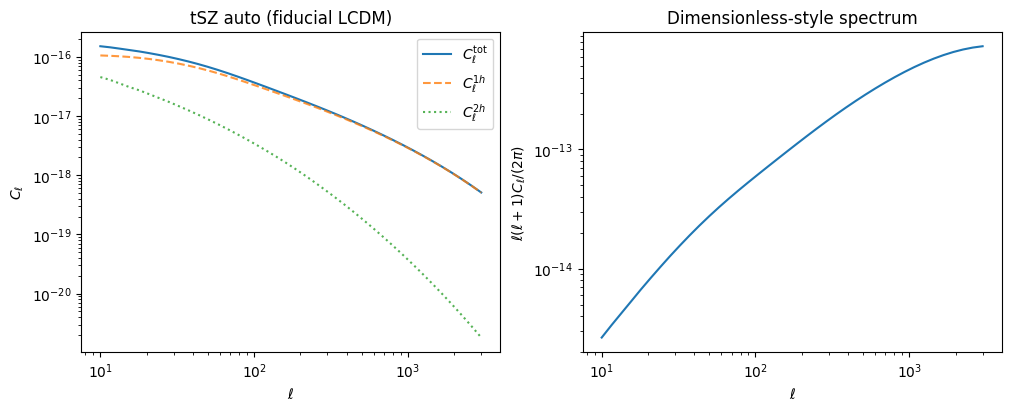

In [6]:
l_np = jnp.asarray(l)
dl = l_np * (l_np + 1) * cl_total / (2 * jnp.pi)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].loglog(l_np, cl_total, label=r"$C_\ell^{\mathrm{tot}}$")
axes[0].loglog(l_np, cl_1h, ls="--", alpha=0.8, label=r"$C_\ell^{1h}$")
axes[0].loglog(l_np, cl_2h, ls=":", alpha=0.8, label=r"$C_\ell^{2h}$")
axes[0].set_xlabel(r"$\ell$")
axes[0].set_ylabel(r"$C_\ell$")
axes[0].legend()
axes[0].set_title("tSZ auto (fiducial LCDM)")

axes[1].loglog(l_np, dl, color="C0")
axes[1].set_xlabel(r"$\ell$")
axes[1].set_ylabel(r"$\ell(\ell+1)C_\ell/(2\pi)$")
axes[1].set_title("Dimensionless-style spectrum")

plt.show()

## Hydrostatic mass bias `B`

The **GNFW** electron-pressure profile takes **`B`** (hydrostatic mass-bias factor in the \(M_{500c}\) normalization; default **`B = 1.4`** in `GNFWPressureProfile`). To change `B`, pass **`GNFWPressureProfile(B=...)`** into **`tSZTracer(profile=...)`**.

Below we fix cosmology and the same **`halo_model`** and \((m,z,\ell)\) grids; only the **profile** changes with **`B`** (via **`tsz.update(...)`** — no new **`HaloModel`**). For speed, the code cell **subsamples** \((m,z,\ell)\) unless you set **`USE_FULL_GRID_FOR_B_SCAN = True`**. **`cl_1h` / `cl_2h`** use **`@jit(static_argnums=(1,2))`**, so each distinct **`B`** can still hit a separate XLA cache entry (first time per value pays compile).

B-scan wall time: 14.17 s


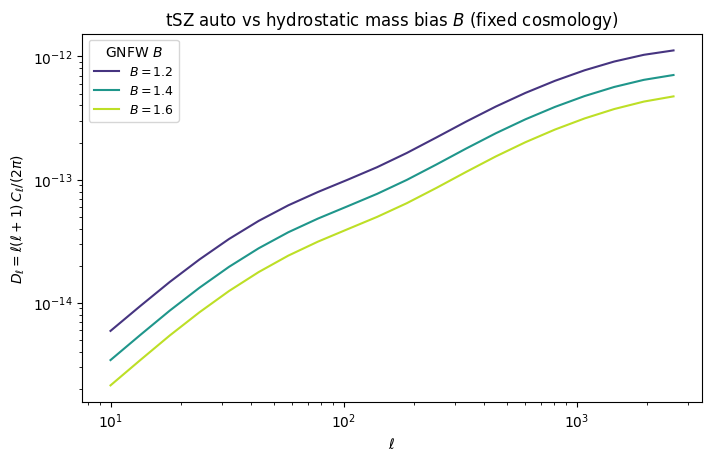

In [9]:
# Scan hydrostatic bias B — reuse `halo_model` and `tsz` from above; only swap the profile per B.
# Slowness: cl_1h / cl_2h are @jit(static_argnums=(1,2)), so each distinct B can get its own XLA
# cache entry (first visit per B pays compile + run). Fewer B values and/or coarser (m,z,l) helps.
import time

USE_FULL_GRID_FOR_B_SCAN = False  # True = same l,m,z as above (slow); False = subsample for speed
B_values = [1.2, 1.4, 1.6]  # add more B only when needed (each new B can trigger compile)

if USE_FULL_GRID_FOR_B_SCAN:
    l_b, m_b, z_b = l, m, z
else:
    l_b = l[::2]
    m_b = m[::2]
    z_b = z[::2]

ell_ax = jnp.asarray(l_b)
t0 = time.perf_counter()
Dell_by_B = {}
for B in B_values:
    tsz_B = tsz.update(profile=GNFWPressureProfile(B=B))
    c1 = halo_model.cl_1h(tsz_B, None, l_b, m_b, z_b)
    c2 = halo_model.cl_2h(tsz_B, None, l_b, m_b, z_b)
    cl_tot_B = (c1 + c2).block_until_ready()
    Dell_by_B[B] = ell_ax * (ell_ax + 1) * cl_tot_B / (2 * jnp.pi)
print(f"B-scan wall time: {time.perf_counter() - t0:.2f} s")

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
colors = plt.cm.viridis(jnp.linspace(0.15, 0.9, len(B_values)))
for i, B in enumerate(B_values):
    ax.loglog(l_b, Dell_by_B[B], color=colors[i], label=rf"$B = {B}$")

ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell = \ell(\ell+1)\,C_\ell/(2\pi)$")
ax.legend(title=r"GNFW $B$", fontsize=9)
ax.set_title(r"tSZ auto vs hydrostatic mass bias $B$ (fixed cosmology)")
plt.show()

## Optional: 3D halo-model power $P_{1h}(k,z)$, $P_{2h}(k,z)$

If you need the **three-dimensional** output at fixed redshift (not Limber-projected), use `HaloModel.pk_1h` and `HaloModel.pk_2h` with the same tracer and mass grid (`halo_model.py`).

**Units (read this before trusting the y-axis):** The generic halo-model docstrings refer to $P(k)$ in $\mathrm{Mpc}^3$ for a **dimensionless** tracer; the tSZ path uses the **Fourier-space profile** $u_k$ built from the **gNFW electron pressure** (NKV-style $P_e$ normalization), so the numerical values are **not** a dimensionless Compton-$y$ power spectrum, and they are **large** in raw code units. The tSZ **line-of-sight kernel** in `tSZTracer.kernel` is folded into the **angular** integrals `cl_1h` / `cl_2h`, **not** into `pk_1h` / `pk_2h`. This section is for API illustration only—label the plot in physical units only after you carry your own unit analysis or map to an observable. **No change to `hmfast` source is required** for that mapping.

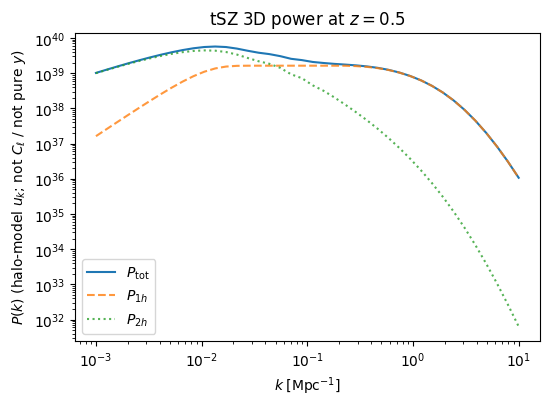

In [8]:
k = jnp.logspace(-3.0, 1.0, 40)
z0 = jnp.array([0.001])

pk_1h = halo_model.pk_1h(tsz, None, k, m, z0)
pk_2h = halo_model.pk_2h(tsz, None, k, m, z0)
pk_tot = pk_1h + pk_2h

plt.figure(figsize=(6, 4))
plt.loglog(k, pk_tot[:, 0], label=r"$P_{\mathrm{tot}}$")
plt.loglog(k, pk_1h[:, 0], ls="--", alpha=0.8, label=r"$P_{1h}$")
plt.loglog(k, pk_2h[:, 0], ls=":", alpha=0.8, label=r"$P_{2h}$")
plt.xlabel(r"$k\;[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)$ (halo-model $u_k$; not $C_\ell$ / not pure $y$)")
plt.legend()
plt.title(r"tSZ 3D power at $z=0.5$")
plt.show()